### Handle data

#### Import library and read data

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from lazypredict.Supervised import LazyClassifier
from sklearn.pipeline import Pipeline

In [2]:
data_df = pd.read_csv('../data/train.csv', index_col='PassengerId')

In [3]:
data_df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [4]:
# Fill the data with sum miss value > 0
missing_data = data_df.isnull().sum()
print(missing_data[missing_data > 0])

Age         177
Cabin       687
Embarked      2
dtype: int64


In [5]:
# Lấy ra target cần dự đoán
target = 'Survived'

In [6]:
x = data_df.drop(columns=[target], axis = 1)
y = data_df[target]

In [7]:
# Stratify ( phân chia để k bị lệch data giữa train và test)
X_train, X_test, Y_train, Y_test = train_test_split(x,y, train_size = 0.8, random_state=1)

In [14]:
# học từ train
embarked_mode = X_train['Embarked'].mode()[0]

# áp dụng cho train và test
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

In [15]:
X_train['Deck'] = X_train['Cabin'].apply(
    lambda x: 'U' if pd.isna(x) else str(x)[0]
)

X_test['Deck'] = X_test['Cabin'].apply(
    lambda x: 'U' if pd.isna(x) else str(x)[0]
)

In [8]:
# Tính median theo nhóm
age_group_median = X_train.groupby(['Sex', 'Pclass'])['Age'].median()

# Median toàn cục (backup)
global_age_median = X_train['Age'].median()

In [9]:
def fill_age(row):
    if pd.notna(row['Age']):
        return row['Age']
    
    key = (row['Sex'], row['Pclass'])
    
    if key in age_group_median.index and pd.notna(age_group_median.loc[key]):
        return age_group_median.loc[key]
    
    return global_age_median

In [10]:
X_train['Age'] = X_train.apply(fill_age, axis=1)
X_test['Age'] = X_test.apply(fill_age, axis=1)

In [12]:
# Sex
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

# Title
X_train['Title'] = X_train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
X_test['Title'] = X_test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

for data in [X_train, X_test]:
    data['Title'] = data['Title'].replace(title_mapping)
    data['Title'] = data['Title'].replace(rare_titles, 'Rare')

In [13]:
# học prefix hiếm từ train
train_ticket_prefix = X_train['Ticket'].str.replace(r'[0-9./]', '', regex=True).str.strip()
train_ticket_prefix = train_ticket_prefix.replace('', 'NONE')

prefix_counts = train_ticket_prefix.value_counts()
rare_prefixes = prefix_counts[prefix_counts < 10].index.tolist()

# áp dụng cho train và test
def make_ticket_prefix(ticket, rare_prefixes):
    prefix = pd.Series([ticket]).str.replace(r'[0-9./]', '', regex=True).str.strip().iloc[0]
    prefix = 'NONE' if prefix == '' else prefix
    return 'RARE' if prefix in rare_prefixes else prefix

X_train['TicketPrefix'] = X_train['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))
X_test['TicketPrefix'] = X_test['Ticket'].apply(lambda x: make_ticket_prefix(x, rare_prefixes))

#### Tạo thêm cột

In [18]:
X_train['Family_Size'] = X_train['SibSp'] + X_train['Parch'] + 1
X_test['Family_Size'] = X_test['SibSp'] + X_test['Parch'] + 1

In [19]:
X_train['IsAlone'] = (X_train['Family_Size'] == 1).astype(int)
X_test['IsAlone'] = (X_test['Family_Size'] == 1).astype(int)

In [20]:
X_train['Surname'] = X_train['Name'].str.split(',').str[0]
X_test['Surname'] = X_test['Name'].str.split(',').str[0]

In [21]:
surname_counts = X_train['Surname'].value_counts()

In [22]:
X_train['SurnameCount'] = X_train['Surname'].map(surname_counts)

X_test['SurnameCount'] = X_test['Surname'].map(surname_counts)

In [23]:
cols_to_drop = ['Cabin', 'Ticket', 'Name']
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 302 to 38
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        712 non-null    int64  
 1   Sex           0 non-null      float64
 2   Age           712 non-null    float64
 3   SibSp         712 non-null    int64  
 4   Parch         712 non-null    int64  
 5   Fare          712 non-null    float64
 6   Embarked      712 non-null    object 
 7   Title         712 non-null    object 
 8   TicketPrefix  712 non-null    object 
 9   Deck          712 non-null    object 
 10  FamilySize    712 non-null    int64  
 11  IsAlone       712 non-null    int32  
 12  Family_Size   712 non-null    float64
 13  Surname       712 non-null    object 
 14  SurnameCount  712 non-null    float64
dtypes: float64(5), int32(1), int64(4), object(5)
memory usage: 86.2+ KB


In [28]:
from sklearn.preprocessing import RobustScaler

num_feature = ['Age', 'Fare', 'SurnameCount', 'Family_Size']

scaler = RobustScaler()


X_train[num_feature] = scaler.fit_transform(X_train[num_feature])
X_test[num_feature] = scaler.transform(X_test[num_feature])

In [32]:
from sklearn.preprocessing import OneHotEncoder

cat_features = ['Embarked', 'Title', 'Deck', 'Surname', 'IsAlone', 'TicketPrefix']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# fit + transform
X_train = encoder.fit_transform(X_train[cat_features])
X_test = encoder.transform(X_test[cat_features])

In [34]:
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 712
Test size: 179


In [35]:
# ============================================
# Bước 4 - Modeling: fit nhiều model, so sánh
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    acc = model.score(X_test, Y_test)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Chọn model tốt nhất (ví dụ theo accuracy)
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\nChọn model: {best_name}")

Logistic Regression: Accuracy = 0.7989
Random Forest: Accuracy = 0.7877
SVM: Accuracy = 0.7933

Chọn model: Logistic Regression


In [41]:
# ============================================
# Bước 6 - Lưu mô hình: joblib.dump / joblib.load
# ============================================
import joblib
import os

# Tạo thư mục chứa model nếu chưa có
os.makedirs('models', exist_ok=True)

# 1. Lưu model và scaler
joblib.dump(best_model, 'models/titanic_model.joblib')
joblib.dump(scaler, 'models/titanic_scaler.joblib')
print("✅ Đã lưu Titanic model và scaler vào thư mục models/")

# 2. Demo: Load và Predict với dữ liệu mới
loaded_model = joblib.load('models/titanic_model.joblib')
loaded_scaler = joblib.load('models/titanic_scaler.joblib')

# 3. Lấy 1 mẫu từ X_test
sample = X_test[:1]

# Nếu X_test đã là dữ liệu sau xử lý để đưa vào model
pred = loaded_model.predict(sample)

# 4. Định nghĩa nhãn thủ công cho Titanic
titanic_labels = ['Perished', 'Survived']

# 5. Hiển thị kết quả
print(f"\nDemo predict - True: {Y_test.iloc[0]}, Predicted: {pred[0]} ({titanic_labels[pred[0]]})")

✅ Đã lưu Titanic model và scaler vào thư mục models/

Demo predict - True: 1, Predicted: 1 (Survived)


In [36]:
from sklearn.metrics import classification_report

# 1. Lấy dự đoán từ tập test
y_pred = best_model.predict(X_test)

# 2. In báo cáo chi tiết
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       106
           1       0.75      0.77      0.76        73

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Quy trình đúng nên là:

- Phân loại (Numeric vs Categorical).

- Phân loại con (Nominal vs Ordinal, Discrete vs Continuous).

- Xử lý dữ liệu thiếu (Imputation).

- Encoding & Scaling.

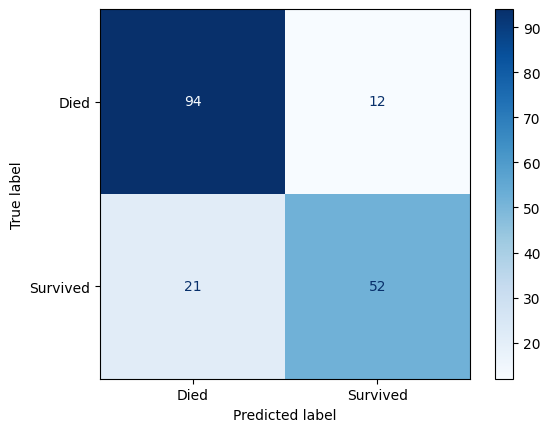

In [ ]:
# # Ma trận nhầm lẫn
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# cm = confusion_matrix(Y_test, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
# disp.plot(cmap='Blues')
# plt.show()

In [ ]:
# #3. Kiểm tra "Học vẹt" (Cross-Validation)
# #Nếu bạn thấy Accuracy trên tập Train là 99% nhưng tập Test chỉ 75%, mô hình của bạn đang bị Overfitting (Học vẹt). Hãy dùng Cross-Validation để xem độ ổn định của nó.
# from sklearn.model_selection import cross_val_score

# # Chia dữ liệu thành 5 phần và chấm điểm 5 lần
# scores = cross_val_score(model_pipeline, x, y, cv=5)

# print(f"Độ chính xác trung bình: {scores.mean():.2%}")
# print(f"Độ lệch (Sự ổn định): {scores.std():.2%}")

Độ chính xác trung bình: 81.82%
Độ lệch (Sự ổn định): 3.16%


In [ ]:
# import joblib

# # Giả sử 'model_pipeline' là Pipeline chứa SVC của bạn đã được .fit()
# # Lưu mô hình vào file .pkl
# joblib.dump(model_pipeline, '../models/titanic_svc_model.pkl')

# print("Đã lưu model SVC thành công!")

Đã lưu model SVC thành công!


In [ ]:
# X_train_transformed = model_pipeline.fit_transform(X_train, Y_train)
# X_test_transformed = model_pipeline.transform(X_test)

In [ ]:
# # Khởi tạo
# lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# # Chú ý thứ tự biến và cách lấy kết quả
# models, predictions = lazy_clf.fit(X_train_transformed, X_test_transformed, Y_train, Y_test)

# # QUAN TRỌNG: In 'models' để thấy bảng xếp hạng
# display(models)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
SVC,0.821229,0.806410,0.831158,0.819298,0.820819,0.821229,0.039261
AdaBoostClassifier,0.810056,0.803373,0.828638,0.810056,0.810056,0.810056,0.113556
NuSVC,0.810056,0.796976,0.821465,0.808600,0.809037,0.810056,0.048145
LinearSVC,0.804469,0.792259,0.825213,0.803255,0.803341,0.804469,0.018952
RidgeClassifierCV,0.804469,0.792259,0.826376,0.803255,0.803341,0.804469,0.028322
RidgeClassifier,0.804469,0.792259,0.825342,0.803255,0.803341,0.804469,0.013394
LinearDiscriminantAnalysis,0.804469,0.792259,0.825730,0.803255,0.803341,0.804469,0.023021
CalibratedClassifierCV,0.798883,0.785410,0.827798,0.797341,0.797663,0.798883,0.060255
LogisticRegression,0.793296,0.782825,0.827927,0.792570,0.792301,0.793296,0.029677
